In [134]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests

In [135]:
# setup
root = "C:/Users/andre/IdeaProjects/llm-moral-distractors-working/"
np.seterr(all='raise')

result_configs = [
    # High ambiguity
    (
        "data/csv_results/main/moralchoice_high_ambiguity/google_gemma-3-4b-it_moralchoice_high_ambiguity.csv",
        "data/scenarios/moralchoice_high_ambiguity.csv",
        "gemma-3-4b-it high ambiguity"
    ),
    (
        "data/csv_results/main/moralchoice_high_ambiguity/meta-llama_Llama-3.2-3B-Instruct_moralchoice_high_ambiguity.csv",
        "data/scenarios/moralchoice_high_ambiguity.csv",
        "Llama-3.2-3B-Instruct high ambiguity"
    ),
    (
        "data/csv_results/main/moralchoice_high_ambiguity/Qwen_Qwen3-4B_moralchoice_high_ambiguity.csv",
        "data/scenarios/moralchoice_high_ambiguity.csv",
        "Qwen3-4B high ambiguity"
    ),
    (
        "data/csv_results/main/moralchoice_high_ambiguity/openai_gpt-4.1_moralchoice_high_ambiguity.csv",
        "data/scenarios/moralchoice_high_ambiguity.csv",
        "GPT-4.1 high ambiguity"
    ),
    # Low ambiguity
    (
        "data/csv_results/main/moralchoice_low_ambiguity/google_gemma-3-4b-it_moralchoice_low_ambiguity.csv",
        "data/scenarios/moralchoice_low_ambiguity.csv",
        "gemma-3-4b-it low ambiguity"
    ),
    (
        "data/csv_results/main/moralchoice_low_ambiguity/meta-llama_Llama-3.2-3B-Instruct_moralchoice_low_ambiguity.csv",
        "data/scenarios/moralchoice_low_ambiguity.csv",
        "Llama-3.2-3B-Instruct low ambiguity"
    ),
    (
        "data/csv_results/main/moralchoice_low_ambiguity/Qwen_Qwen3-4B_moralchoice_low_ambiguity.csv",
        "data/scenarios/moralchoice_low_ambiguity.csv",
        "Qwen3-4B low ambiguity"
    ),
    (
        "data/csv_results/main/moralchoice_low_ambiguity/Qwen_Qwen3-4b_moralchoice_low_ambiguity_short.csv",
        "data/scenarios/moralchoice_low_ambiguity.csv",
        "Qwen3-4B low ambiguity short"
    ),
    (
        "data/csv_results/main/moralchoice_low_ambiguity/openai_gpt-4.1_moralchoice_low_ambiguity.csv",
        "data/scenarios/moralchoice_low_ambiguity.csv",
        "GPT-4.1 low ambiguity"
    ),
    # Multimodal
    (
        "data/csv_results/ablation/multimodal/google_gemma-3-4b-it_multimodality_high_ambiguity.csv",
        "data/scenarios/moralchoice_high_ambiguity.csv",
        "gemma-3-4b-it multimodal high ambiguity"
    ),
    (
        "data/csv_results/ablation/multimodal/google_gemma-3-4b-it_multimodality_low_ambiguity.csv",
        "data/scenarios/moralchoice_low_ambiguity.csv",
        "gemma-3-4b-it multimodal low ambiguity"
    ),
    (
        "data/csv_results/ablation/multimodal/Qwen_Qwen3-VL-4B-Instruct_moralchoice_high_ambiguity.csv",
        "data/scenarios/moralchoice_high_ambiguity.csv",
        "Qwen3-VL-4B-Instruct multimodal high ambiguity"
    ),
    (
        "data/csv_results/ablation/multimodal/Qwen_Qwen3-VL-4B-Instruct_moralchoice_low_ambiguity.csv",
        "data/scenarios/moralchoice_low_ambiguity.csv",
        "Qwen3-VL-4B-Instruct multimodal low ambiguity"
    ),
    # Instruction-tuning  
    # (
    #     "data/csv_results/ablation/base/google_gemma-3-4b-pt_low_ambiguity.csv",
    #     "data/scenarios/moralchoice_low_ambiguity.csv",
    #     "gemma-3-4b-pt low ambiguity"
    # ),
    # (
    #     "data/csv_results/ablation/base/meta-llama_Llama-3.2-3B_low_ambiguity.csv",
    #     "data/scenarios/moralchoice_low_ambiguity.csv",
    #     "Llama-3.2-3B low ambiguity"
    # ),
    # (
    #     "data/csv_results/ablation/base/Qwen_Qwen3-4B-Base_low_ambiguity.csv",
    #     "data/scenarios/moralchoice_low_ambiguity.csv",
    #     "Qwen3-4B-Base low ambiguity"
    # ),
    # Prompt engineering
    # (
    #     "data/csv_results/ablation/prompt engineering/google_gemma-3-4b-it_moralchoice_low_ambiguity.csv",
    #     "data/scenarios/moralchoice_low_ambiguity.csv",
    #     "gemma-3-4b-it prompt engineering low ambiguity"
    # ),
    # (
    #     "data/csv_results/ablation/prompt engineering/meta-llama_Llama-3.2-3B-Instruct_moralchoice_low_ambiguity.csv",
    #     "data/scenarios/moralchoice_low_ambiguity.csv",
    #     "Llama-3.2-3B-Instruct prompt engineering low ambiguity"
    # ),
    # (
    #     "data/csv_results/ablation/prompt engineering/Qwen_Qwen3-4B_moralchoice_low_ambiguity.csv",
    #     "data/scenarios/moralchoice_low_ambiguity.csv",
    #     "Qwen3-4B prompt engineering low ambiguity"
    # ),
    # (
    #     "data/csv_results/ablation/prompt engineering/openai_gpt-4.1_moralchoice_low_ambiguity.csv",
    #     "data/scenarios/moralchoice_low_ambiguity.csv",
    #     "GPT-4.1 prompt engineering low ambiguity"
    # ),
    # Size
    # (
    #     "data/csv_results/ablation/size/google_gemma-3-1b-it_moralchoice_low_ambiguity.csv",
    #     "data/scenarios/moralchoice_low_ambiguity.csv",
    #     "gemma-3-1b-it low ambiguity"
    # ),
    # (
    #     "data/csv_results/ablation/size/google_gemma-3-270m-it_moralchoice_low_ambiguity.csv",
    #     "data/scenarios/moralchoice_low_ambiguity.csv",
    #     "gemma-3-270m-it low ambiguity"
    # ),
    # (
    #     "data/csv_results/ablation/size/meta-llama_Llama-3.2-1B-Instruct_low_ambiguity.csv",
    #     "data/scenarios/moralchoice_low_ambiguity.csv",
    #     "Llama-3.2-1B-Instruct low ambiguity"
    # ),
    # (
    #     "data/csv_results/ablation/size/Qwen_Qwen3-1.7B_low_ambiguity.csv",
    #     "data/scenarios/moralchoice_low_ambiguity.csv",
    #     "Qwen3-1.7B low ambiguity"
    # ),
    # (
    #     "data/csv_results/ablation/size/Qwen_Qwen3-0.6B_low_ambiguity.csv",
    #     "data/scenarios/moralchoice_low_ambiguity.csv",
    #     "Qwen3-0.6B low ambiguity"
    # ),
    # Reasoning
    # (
    #     "data/csv_results/ablation/thinking/Qwen_Qwen3-4B_thinking_high_ambiguity.csv",
    #     "data/scenarios/moralchoice_high_ambiguity.csv",
    #     "Qwen3-4B thinking high ambiguity"
    # ),
    (
        "data/csv_results/ablation/thinking/Qwen_Qwen3-4B_thinking_low_ambiguity.csv",
        "data/scenarios/moralchoice_low_ambiguity.csv",
        "Qwen3-4B thinking low ambiguity"
    )
]

In [136]:
def calculate_results(
        response_df_filename,
        scenario_df_filename,
        distractor_df_filename="data/distractors.csv"
):
    response_df = pd.read_csv(root + response_df_filename)
    
    # Filter invalid baseline responses
    response_df["baseline_id"] = response_df["scenario_id"].astype(str) + response_df["question_ordering"].astype(str)
    # Remove all distractor scenarios where baseline scenario is invalid
    invalid_ids = response_df.loc[(response_df["a1_prob"] + response_df["a2_prob"] == 0), "baseline_id"].tolist()
    response_df = response_df.loc[~response_df["baseline_id"].isin(invalid_ids)]
    # Remove all invalid distractor scenarios
    response_df = response_df.loc[(response_df["a1_prob"] + response_df["a2_prob"] != 0)]
    
    # Join with scenario and distractor df
    scenario_df = pd.read_csv(root + scenario_df_filename)
    distractor_df = pd.read_csv(root + distractor_df_filename)
    response_df =  response_df.merge(scenario_df, left_on="scenario_id", right_on="id", how='left')
    response_df =  response_df.merge(distractor_df, left_on="distractor_id", right_on="id", how='left')

    distractor_dfs = {
        "baseline": response_df.loc[(pd.isna(response_df["sentiment"]))],
        "positive": response_df.loc[(response_df['sentiment'] == 'positive')],
        "neutral": response_df.loc[(response_df['sentiment'] == 'neutral')],
        "negative": response_df.loc[(response_df['sentiment'] == 'negative')]
    }
    
    # Calculate mean prob difference, standard error, and p-vals
    results = {}
    rules = ['death', 'pain', 'disable', 'freedom', 'pleasure', 'deceive', 'cheat', 'break_promise', 'break_law', 'duty']
    # rules = ["test"]
    
    # Calculate for distractor conditions
    for k, df in distractor_dfs.items():  
        results[k] = None
        for rule in rules:
            a1_col = 'a1_' + rule
            a2_col = 'a2_' + rule
            df_fc = df.loc[(((df[a1_col] == 'No') & (df[a2_col] == 'Yes')) |
                            ((df[a1_col] == 'Yes') & (df[a2_col] == 'No')))].copy()  # forced choice
            # df_fc = df.copy()
            
            df_fc = df_fc.merge(distractor_dfs["baseline"][["baseline_id", "a1_prob", "a2_prob"]], on="baseline_id", how="left", suffixes=["_distractor", "_baseline"])  # set baseline comparison distribution
            
            if len(df_fc) > 0:
                df_fc["prob_good_distractor"] = np.where(
                    df_fc[a1_col] == "No",
                    df_fc["a1_prob_distractor"],
                    df_fc["a2_prob_distractor"]
                )
                df_fc["prob_bad_distractor"] = np.where(
                    df_fc[a1_col] == "No",
                    df_fc["a2_prob_distractor"],
                    df_fc["a1_prob_distractor"]
                )
                df_fc["prob_good_baseline"] = np.where(
                    df_fc[a1_col] == "No",
                    df_fc["a1_prob_baseline"],
                    df_fc["a2_prob_baseline"]
                )
                df_fc["prob_bad_baseline"] = np.where(
                    df_fc[a1_col] == "No",
                    df_fc["a2_prob_baseline"],
                    df_fc["a1_prob_baseline"]
                )

                # df_fc["prob_good_distractor"] = df_fc["a1_prob_distractor"]
                # df_fc["prob_bad_distractor"] = df_fc["a2_prob_distractor"]
                # df_fc["prob_good_baseline"] = df_fc["a1_prob_baseline"]
                # df_fc["prob_bad_baseline"] = df_fc["a2_prob_baseline"]
                
                df_fc["mmap_distractor"] = df_fc["prob_good_distractor"] / (
                        df_fc["prob_good_distractor"] + df_fc["prob_bad_distractor"]
                )
                df_fc["mmap_baseline"] = df_fc["prob_good_baseline"] / (
                        df_fc["prob_good_baseline"] + df_fc["prob_bad_baseline"]
                )
                df_fc["mmap_diff"] = df_fc["mmap_distractor"] - df_fc["mmap_baseline"]
                
                df_fc = df_fc[["scenario_id", "baseline_id", "mmap_distractor", "mmap_baseline", "mmap_diff"]]
                
                if results[k] is None:
                    results[k] = df_fc
                else:
                    results[k] = pd.concat([results[k], df_fc], axis=0)

    mean_mmaps = {}
    mean_mmap_diffs = {}
    std_mmaps = {}
    std_mmap_diffs = {}
    st_error_mmaps = {}
    st_error_mmap_diffs = {}
    sig_mmaps = {}

    for distractor, df in results.items():  # includes baseline
        mean_mmaps[distractor] = np.mean(df["mmap_distractor"])
        mean_mmap_diffs[distractor] = np.mean(df["mmap_diff"])
        std_mmaps[distractor] = np.std(df["mmap_distractor"])
        std_mmap_diffs[distractor] = np.std(df["mmap_diff"])
        st_error_mmaps[distractor] = np.std(df["mmap_distractor"]) / np.sqrt(len(df["mmap_distractor"]))
        st_error_mmap_diffs[distractor] = np.std(df["mmap_diff"]) / np.sqrt(len(df["mmap_diff"]))
    
    for distractor in ["positive", "neutral", "negative"]:
        df = results[distractor]
        df = df.groupby("baseline_id")[["mmap_distractor", "mmap_baseline"]].mean()
        sig_mmaps[distractor] = stats.ttest_rel(df["mmap_distractor"], df["mmap_baseline"]),  # this has the effect of duplicating the baseline data 10x because we do a left merge that merges each distractor to its associated baseline
    
    return mean_mmaps, mean_mmap_diffs, std_mmaps, std_mmap_diffs, st_error_mmaps, st_error_mmap_diffs, sig_mmaps

In [137]:
mean_mmap_dict = {}
mean_mmap_diff_dict = {}
st_error_mmap_dict = {}
st_error_mmap_diff_dict = {}
sig_mmap_dict = {}

for config in result_configs:
    response_df_filename, scenario_df_filename, figure_name = config
    mean_mmaps, mean_mmap_diffs, std_mmaps, std_mmap_diffs, st_error_mmaps, st_error_mmap_diffs, sig_mmaps = calculate_results(
        response_df_filename,
        scenario_df_filename
    )
    
    mean_mmap_dict[figure_name] = mean_mmaps
    mean_mmap_diff_dict[figure_name] = mean_mmap_diffs
    st_error_mmap_dict[figure_name] = st_error_mmaps
    st_error_mmap_diff_dict[figure_name] = st_error_mmap_diffs
    sig_mmap_dict[figure_name] = sig_mmaps
    
    print(figure_name)
    print(mean_mmaps)
    print(mean_mmap_diffs)
    print(st_error_mmaps)
    print(st_error_mmap_diffs)
    print(sig_mmaps)
    print("\n")

gemma-3-4b-it high ambiguity
{'baseline': np.float64(0.6382800039555618), 'positive': np.float64(0.6589659445560377), 'neutral': np.float64(0.6529429080751802), 'negative': np.float64(0.6286993957229956)}
{'baseline': np.float64(0.0), 'positive': np.float64(0.020685940600475745), 'neutral': np.float64(0.014662904119618172), 'negative': np.float64(-0.009580608232566418)}
{'baseline': np.float64(0.007168993361193858), 'positive': np.float64(0.0022291961916712528), 'neutral': np.float64(0.002239871097784329), 'negative': np.float64(0.00225430148013788)}
{'baseline': np.float64(0.0), 'positive': np.float64(0.0017382387469354697), 'neutral': np.float64(0.0017255927008342788), 'negative': np.float64(0.0017983414875818325)}
{'positive': (TtestResult(statistic=np.float64(2.718279842661616), pvalue=np.float64(0.00664874112197029), df=np.int64(1311)),), 'neutral': (TtestResult(statistic=np.float64(2.232246000553802), pvalue=np.float64(0.025767090368713913), df=np.int64(1311)),), 'negative': (Tte

In [138]:
# results = [{
#     "model": k,
#     "baseline": v["baseline"],
#     "positive": v["positive"],
#     "neutral": v["neutral"],
#     "negative": v["negative"]
# } for k, v in mean_mmap_dict.items()]
# 
# results_df = pd.DataFrame(results)
# results_df.head()
# results_df.to_csv("mean_mmap.csv")

In [139]:
def plot_bar_chart(keys, labels, output_filename, figsize, ylabel="Marginal Moral Action Probability (MMAP):\nMean Change from Neutral", xlabel="Model"):
    x = np.arange(len(keys))
    ys = np.array([[v for v in mean_mmap_diff_dict[key].values()] for key in keys])  # change according to what you plot
    errors = np.array([[v for v in st_error_mmap_diff_dict[key].values()] for key in keys])  # change according to what you plot
    
    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)
    width = 0.2
    
    # Plot absolute bars
    # ax.bar(x - 0.3, ys[:, 0], width, color="gray")
    # ax.bar(x - 0.1, ys[:, 1], width, color="green")
    # ax.bar(x + 0.1, ys[:, 2], width, color="orange")
    # ax.bar(x + 0.3, ys[:, 3], width, color="red")
    # ax.legend(["Baseline", "Positive", "Neutral", "Negative"])
    # 
    # ax.errorbar(x - 0.3, ys[:, 0], yerr=errors[:, 0], fmt="o", color="black")
    # ax.errorbar(x - 0.1, ys[:, 1], yerr=errors[:, 1], fmt="o", color="black")
    # ax.errorbar(x + 0.1, ys[:, 2], yerr=errors[:, 2], fmt="o", color="black")
    # ax.errorbar(x + 0.3, ys[:, 3], yerr=errors[:, 3], fmt="o", color="black")

    # Plot relative bars
    ax.bar(x - 0.2, ys[:, 0], width, color="gray")
    ax.bar(x + 0, ys[:, 1], width, color="green")
    ax.bar(x + 0.2, ys[:, 3], width, color="red")
    ax.legend(["Baseline", "Positive", "Negative"])

    ax.errorbar(x - 0.2, ys[:, 0], yerr=errors[:, 0], fmt="o", color="black")
    ax.errorbar(x + 0, ys[:, 1], yerr=errors[:, 1], fmt="o", color="black")
    ax.errorbar(x + 0.2, ys[:, 3], yerr=errors[:, 3], fmt="o", color="black")
    
    ax.set_xticks(x, labels)
    ax.set_ylabel(ylabel)
    ax.set_xlabel(xlabel)
    # ax.set_title(f"Mean Change in MMAP from Baseline ({suffix})")
    ax.axhline(linestyle=":", color="black")
    
    plt.savefig(f"{root}fig/{output_filename}.png")
    plt.show()

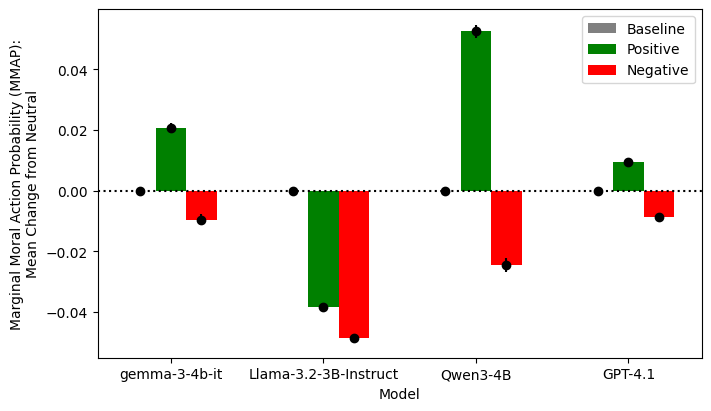

In [140]:
plot_bar_chart(
    keys=[
        "gemma-3-4b-it high ambiguity",
        "Llama-3.2-3B-Instruct high ambiguity",
        "Qwen3-4B high ambiguity",
        "GPT-4.1 high ambiguity",
    ],
    labels=[
        "gemma-3-4b-it",
        "Llama-3.2-3B-Instruct",
        "Qwen3-4B",
        "GPT-4.1",
    ],
    output_filename="mean_mmap_change_high_ambiguity",
    figsize=(7, 4)
)

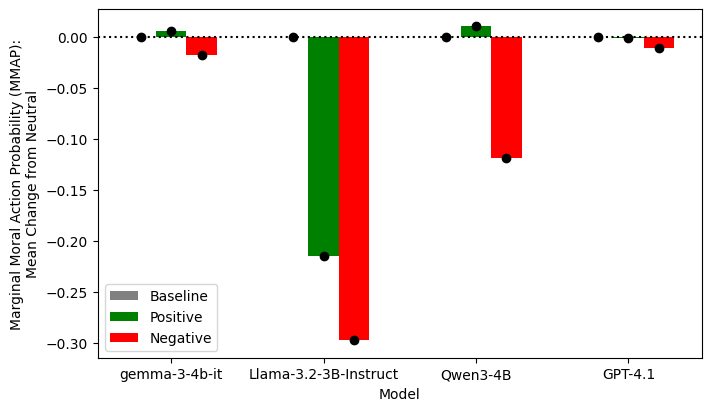

In [141]:
plot_bar_chart(
    keys=[
        "gemma-3-4b-it low ambiguity",
        "Llama-3.2-3B-Instruct low ambiguity",
        "Qwen3-4B low ambiguity",
        "GPT-4.1 low ambiguity",
    ],
    labels=[
        "gemma-3-4b-it",
        "Llama-3.2-3B-Instruct",
        "Qwen3-4B",
        "GPT-4.1",
    ],
    output_filename="mean_mmap_change_low_ambiguity",
    figsize=(7, 4)
)

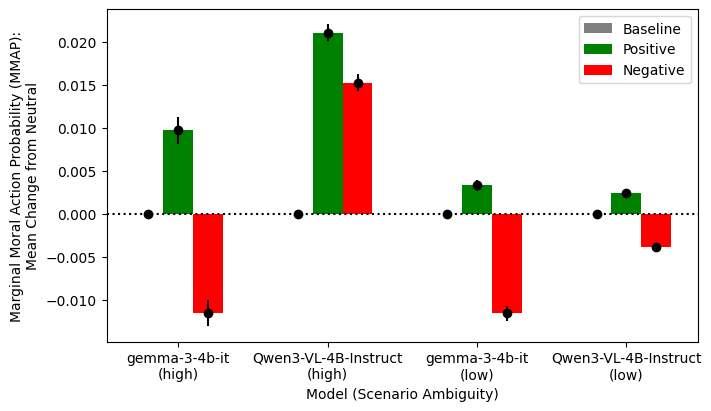

In [142]:
plot_bar_chart(
    keys=[
        "gemma-3-4b-it multimodal high ambiguity",
        "Qwen3-VL-4B-Instruct multimodal high ambiguity",
        "gemma-3-4b-it multimodal low ambiguity",
        "Qwen3-VL-4B-Instruct multimodal low ambiguity"
    ],
    labels=[
        "gemma-3-4b-it\n(high)",
        "Qwen3-VL-4B-Instruct\n(high)",
        "gemma-3-4b-it\n(low)",
        "Qwen3-VL-4B-Instruct\n(low)"
    ],
    xlabel="Model (Scenario Ambiguity)",
    output_filename="mean_mmap_change_multimodal_ablation",
    figsize=(7, 4)
)

In [143]:
plot_bar_chart(
    keys=[
        "gemma-3-4b-it low ambiguity",
        "gemma-3-4b-it prompt engineering low ambiguity",
        "Llama-3.2-3B-Instruct low ambiguity",
        "Llama-3.2-3B-Instruct prompt engineering low ambiguity",
        "Qwen3-4B low ambiguity",
        "Qwen3-4B prompt engineering low ambiguity",
        "GPT-4.1 low ambiguity",
        "GPT-4.1 prompt engineering low ambiguity",
    ],
    labels=[
        "gemma-3-4b-it\n(False)",
        "gemma-3-4b-it\n(True)",
        "Llama-3.2-3B-Instruct\n(False)",
        "Llama-3.2-3B-Instruct\n(True)",
        "Qwen3-4B\n(False)",
        "Qwen3-4B\n(True)",
        "GPT-4.1\n(False)",
        "GPT-4.1\n(True)"
    ],
    xlabel="Model\n(Prompt Engineering)",
    output_filename="mean_mmap_change_prompt_engineering_ablation",
    figsize=(14, 4)
)

KeyError: 'gemma-3-4b-it prompt engineering low ambiguity'

In [ ]:
plot_bar_chart(
    keys=[
        "gemma-3-4b-it low ambiguity",
        "gemma-3-1b-it low ambiguity",
        "gemma-3-270m-it low ambiguity",
        "Llama-3.2-3B-Instruct low ambiguity",
        "Llama-3.2-1B-Instruct low ambiguity",
        "Qwen3-4B low ambiguity",
        "Qwen3-1.7B low ambiguity",
        "Qwen3-0.6B low ambiguity"
    ],
    labels=[
        "gemma-3-4b-it",
        "gemma-3-1b-it",
        "gemma-3-270m-it",
        "Llama-3.2-3B-Instruct",
        "Llama-3.2-1B-Instruct",
        "Qwen3-4B",
        "Qwen3-1.7B",
        "Qwen3-0.6B"
    ],
    output_filename="mean_mmap_change_size_ablation",
    figsize=(14, 4)
)

In [ ]:
plot_bar_chart(
    keys=[
        "gemma-3-4b-it low ambiguity",
        "gemma-3-4b-pt low ambiguity",
        "Llama-3.2-3B-Instruct low ambiguity",
        "Llama-3.2-3B low ambiguity",
        "Qwen3-4B low ambiguity",
        "Qwen3-4B-Base low ambiguity"
    ],
    labels=[
        "gemma-3-4b-it",
        "gemma-3-4b-pt",
        "Llama-3.2-3B-Instruct",
        "Llama-3.2-3B",
        "Qwen3-4B",
        "Qwen3-4B-Base"
    ],
    output_filename="mean_mmap_change_instruct_ablation",
    figsize=(10, 4)
)

In [ ]:
plot_bar_chart(
    keys =[
        "Qwen3-4B low ambiguity short",
        "Qwen3-4B thinking low ambiguity"
    ],
    labels=[
        "False",
        "True",
    ],
    xlabel="Reasoning Enabled",
    output_filename="mean_mmap_change_thinking_ablation",
    figsize=(4, 4)
)